/var/folders/ht/yrqh6nts66lfspsb44qlvw5c0000gn/T/ipykernel_58852/3181183871.py:7: DtypeWarning: Columns (9,1729,1743,1909,1910,1911,1912,1913,2251,2252,2254,2256,2258) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


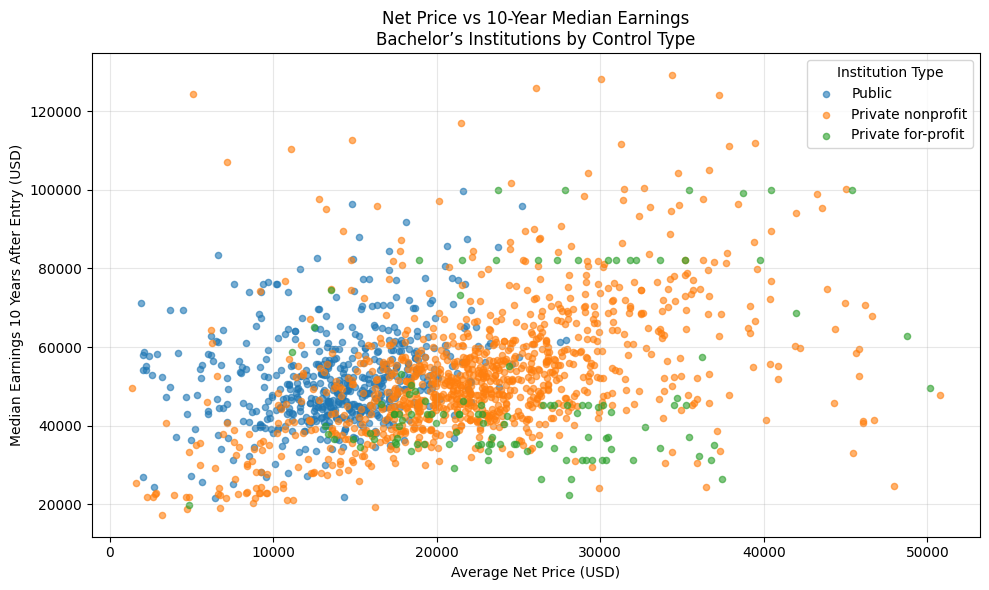

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the data
# Make sure this filename matches your actual file path
df = pd.read_csv(
    "college-scorecard-institution.csv",
    na_values=["PrivacySuppressed", "NULL", "NA", "PS"]
)

# 2. Filter for bachelor's-degree-predominant institutions
# PREDDEG: 3 = predominantly bachelor's-degree granting
df = df[df["PREDDEG"] == 3]

# 3. Keep only the columns we need
cols_needed = [
    "CONTROL",          # sector/ownership
    "NPT4_PUB",         # net price for public schools
    "NPT4_PRIV",        # net price for private schools
    "MD_EARN_WNE_P10"   # median earnings 10 years after entry
]
df = df[cols_needed].copy()

# 4. Create a unified net price variable
# If public (CONTROL == 1) -> use NPT4_PUB
# If private (CONTROL == 2 or 3) -> use NPT4_PRIV
df["net_price"] = np.where(
    df["CONTROL"] == 1,
    df["NPT4_PUB"],
    df["NPT4_PRIV"]
)

# 5. Clean numeric columns (in case they’re strings)
df["net_price"] = pd.to_numeric(df["net_price"], errors="coerce")
df["MD_EARN_WNE_P10"] = pd.to_numeric(df["MD_EARN_WNE_P10"], errors="coerce")

# 6. Drop rows with missing or non-positive net price or earnings
df = df.dropna(subset=["net_price", "MD_EARN_WNE_P10"])
df = df[(df["net_price"] > 0) & (df["MD_EARN_WNE_P10"] > 0)]

# 7. Map CONTROL to labels and colors
control_labels = {
    1: "Public",
    2: "Private nonprofit",
    3: "Private for-profit"
}

control_colors = {
    1: "tab:blue",
    2: "tab:orange",
    3: "tab:green"
}

# 8. Create the scatter plot
plt.figure(figsize=(10, 6))

for control_value, label in control_labels.items():
    subset = df[df["CONTROL"] == control_value]
    if subset.empty:
        continue
    plt.scatter(
        subset["net_price"],
        subset["MD_EARN_WNE_P10"],
        label=label,
        alpha=0.6,
        s=20,
        c=control_colors[control_value]
    )

plt.xlabel("Average Net Price (USD)")
plt.ylabel("Median Earnings 10 Years After Entry (USD)")
plt.title("Net Price vs 10-Year Median Earnings\nBachelor’s Institutions by Control Type")
plt.legend(title="Institution Type")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
